In [39]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
df = yf.download("GC=F", start='2005-01-01')
df.columns = df.columns.droplevel(1)
df['return'] = df['Close'].pct_change()
print(df['return'].describe())
df['return'].idxmax()
print(f"Five Best Returns: {df['return'].nlargest(5)}")
print(f"Five Worst Returns: {df['return'].nsmallest(5)}")
print(f"Skewness: {df['return'].skew()}")
print(f"Kurtosis: {df['return'].kurtosis()}")



[*********************100%***********************]  1 of 1 completed

count    5366.000000
mean        0.000514
std         0.011513
min        -0.113662
25%        -0.004876
50%         0.000528
75%         0.006425
max         0.090277
Name: return, dtype: float64
Five Best Returns: Date
2008-09-17    0.090277
2009-03-19    0.078317
2026-02-03    0.060833
2020-03-24    0.059477
2008-11-21    0.057574
Name: return, dtype: float64
Five Worst Returns: Date
2026-01-30   -0.113662
2013-04-15   -0.093538
2006-06-13   -0.073006
2013-06-20   -0.063847
2026-03-19   -0.059142
Name: return, dtype: float64
Skewness: -0.38887602796386606
Kurtosis: 6.520183706669948


#Observations:
1. The mean for the daily returns is quite low compared to that of nifty 50.
2. STD for a asset like this with less returns is quite high sitting at 0.01.
3. median is to the right of the mean which shows left fat tail. that is also clear from the -ve skewness value.
4. min return has gone to -11% which is huge is also evident from the kurtosis value of 6.5 which shows the its quite fat tail.
5. 4/5 max returns happened during the ressesion which show us that got is something which increases in value in crisis.
6. In 2026 gold decreased the greatest and then also had one of its biggest rallies as well.


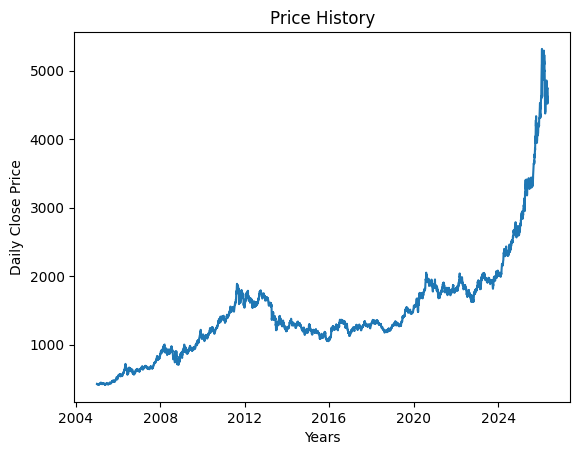

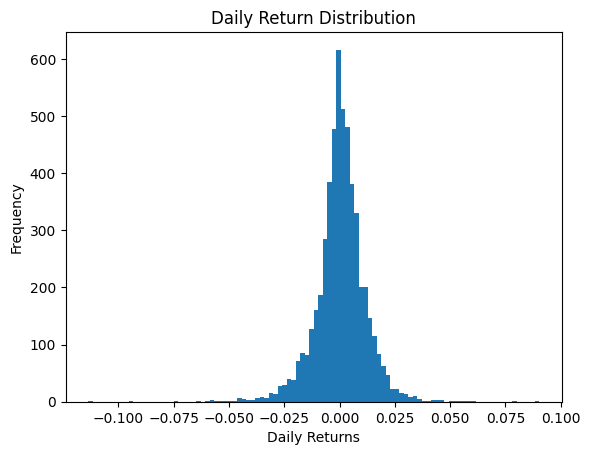

In [41]:
plt.plot(df['Close'])
plt.title('Price History')
plt.xlabel('Years')
plt.ylabel('Daily Close Price')
plt.show()

plt.hist(df['return'], bins=100)
plt.title('Daily Return Distribution')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.show()


#Observations:
1. In the recent years gold is its all time high prices which may be also shows that the economy is not stable.
2. The return distributions is Leptokurtic which also shows excess +ve kurtosis. 
3. fat tail om the left is also evident from the distribution.

In [61]:
df_year_std = df['return'].groupby(df.index.year).std()*(252**0.5)
df_year_std = pd.DataFrame(df_year_std)
df_year_std.columns = ['Annual Volatility']
df_year_std['note'] = 'standard entry'
df_year_std.loc[2026, 'note'] = 'Partial Year Data'
print(df_year_std)
print(f"Max volatility Years: {df_year_std['Annual Volatility'].nlargest(5)}")

      Annual Volatility               note
Date                                      
2005           0.124232     standard entry
2006           0.238887     standard entry
2007           0.165395     standard entry
2008           0.305738     standard entry
2009           0.221538     standard entry
2010           0.159724     standard entry
2011           0.210457     standard entry
2012           0.162928     standard entry
2013           0.222402     standard entry
2014           0.142206     standard entry
2015           0.147285     standard entry
2016           0.162737     standard entry
2017           0.103918     standard entry
2018           0.105433     standard entry
2019           0.115315     standard entry
2020           0.214413     standard entry
2021           0.149104     standard entry
2022           0.155061     standard entry
2023           0.132406     standard entry
2024           0.149748     standard entry
2025           0.204679     standard entry
2026       

#Observations:
1. Max volatility happened in the years which were most unstable and it is evendent from the recent war activity as well.
2. Assets that normally don't move together start moving together — including gold — because the driver isn't fundamentals, it's forced liquidation. Everyone sells what they can, not what they want to.